# COSC2671 Social Media and Network Analytics
## Assignment 2 – Samsung vs iPhone Analysis

## Authors:
### Ritik Kadwane
### Ngoc Anh Thu Nguyen

# Load all the needed library

In [3]:
import json
from pathlib import Path
import pandas as pd
import re
import html
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Introduction

For this project, we looking at online users discussions about two popular brands which are iPhone and Samsung. These two are usually compared by lots of consumers, especially when people discuss camera quality, battery life, price, software, and overall user experience.

Our analysis uses data from Reddit and YouTube because both platforms contain many public comments and opinions from users. In this notebook, we first load and organise the collected data, then clean and explore the comments before moving on to text analysis, sentiment analysis, and network analysis.


# 2. Data Collection

As our first step, we load the Reddit and YouTube data that we collected for the iPhone and Samsung topic from Reddit and YouTube. Since the data was saved in a JSON format, we started by reading the files, examining the collection information, and verifying the structure of the datasets before proceeding with the analysis.

In [7]:
# Set the file paths for the two JSON files
reddit_json_path = Path("reddit_data.json")
youtube_json_path = Path("youtube_data.json")

# Open and read the Reddit JSON file
with open(reddit_json_path, "r", encoding="utf-8") as reddit_file:
    reddit_raw = json.load(reddit_file)

# Open and read the YouTube JSON file
with open(youtube_json_path, "r", encoding="utf-8") as youtube_file:
    youtube_raw = json.load(youtube_file)

# Check the data type of each loaded JSON file
print("Reddit data type:", type(reddit_raw))
print("YouTube data type:", type(youtube_raw))

Reddit data type: <class 'dict'>
YouTube data type: <class 'dict'>


In [272]:
# Print some basic information about the Reddit data collection
print("Reddit platform:", reddit_raw["platform"])
print("Reddit source:", reddit_raw["source"])
print("Reddit collected at:", reddit_raw["collectedAt"])
print("Total Reddit posts:", reddit_raw["totalPosts"])
print("Total Reddit comments:", reddit_raw["totalComments"])

print()

# Print some basic information about the YouTube data collection
print("YouTube platform:", youtube_raw["platform"])
print("YouTube source:", youtube_raw["source"])
print("YouTube collected at:", youtube_raw["collectedAt"])
print("Total YouTube videos:", youtube_raw["totalVideos"])
print("Total YouTube comments:", youtube_raw["totalComments"])

Reddit platform: reddit
Reddit source: Arctic Shift API
Reddit collected at: 2026-05-21T12:04:24Z
Total Reddit posts: 42
Total Reddit comments: 11610

YouTube platform: youtube
YouTube source: YouTube Data API v3
YouTube collected at: 2026-05-21T12:19:56Z
Total YouTube videos: 3
Total YouTube comments: 40910


In [273]:
# Store the actual Reddit posts and YouTube videos in separate variables
reddit_posts_list = reddit_raw["posts"]
youtube_videos_list = youtube_raw["videos"]

# Check how many main records are inside each dataset
print("Number of Reddit posts:", len(reddit_posts_list))
print("Number of YouTube videos:", len(youtube_videos_list))

Number of Reddit posts: 42
Number of YouTube videos: 3


In [274]:
# Convert the Reddit posts and YouTube videos into pandas tables
reddit_posts_table = pd.DataFrame(reddit_posts_list)
youtube_videos_table = pd.DataFrame(youtube_videos_list)

# Also checking the number of rows and columns in each table
print("Reddit posts table shape:", reddit_posts_table.shape)
print("YouTube videos table shape:", youtube_videos_table.shape)

Reddit posts table shape: (42, 9)
YouTube videos table shape: (3, 13)


In [275]:
# Show the first few rows to see how the data looks in table format
display(reddit_posts_table.head())
display(youtube_videos_table.head())

,title,postId,subreddit,author,publishedAt,score,numComments,url,comments
0,Iphones are so overrated...,1l0i3nb,Smartphones,VideoAffectionate977,2025-06-01T06:21:01Z,330,357,https://www.reddit.com/r/Smartphones/comments/...,"[{'commentId': 'nejxslg', 'author': 'Ram2145',..."
1,Moving back to iOS: The uncomfortable truth,1nm3cgm,Smartphones,MrSincerao,2025-09-20T16:55:03Z,154,509,https://www.reddit.com/r/Smartphones/comments/...,"[{'commentId': 'nj9kzji', 'author': 'waltercon..."
2,"Just switched from Android to iOS, and….",1nzjpui,Smartphones,GADG3Tx87,2025-10-06T13:54:36Z,143,237,https://www.reddit.com/r/Smartphones/comments/...,"[{'commentId': 'nwer5tv', 'author': 'fartknock..."
3,Samsung VS iPhone,1ou7vdg,Smartphones,No_Tax8005,2025-11-11T12:13:39Z,37,187,https://www.reddit.com/r/Smartphones/comments/...,"[{'commentId': 'oklguqk', 'author': 'Southern_..."
4,"I don’t like iPhones, I’m not a fan of Samsung...",1lkw2zi,Smartphones,Nice-Ad6855,2025-06-26T09:51:52Z,49,182,https://www.reddit.com/r/Smartphones/comments/...,"[{'commentId': 'n3rtlyl', 'author': 'squarey3t..."


,title,videoId,channelId,channelTitle,publishedAt,duration,viewCount,likeCount,numComments,description,tags,url,comments
0,Is Samsung Better than Apple!? [I TESTED Both ...,fmThG8pnnmA,UCzlXf-yUIaOpOjEjPrOO9TA,The Tech Chap,2024-08-07T17:14:10Z,PT21M34S,1229697,25713,3057,"Apple vs Samsung: iPhone vs Galaxy, iPad vs Ta...","[apple vs samsung, samsung s24 ultra, iphone 1...",https://www.youtube.com/watch?v=fmThG8pnnmA,"[{'commentId': 'UgwycKvNuuMO0iQe1R54AaABAg', '..."
1,iPhone vs Android (The Real Winner)!,nHkKJ87FS6s,UCBJycsmduvYEL83R_U4JriQ,Marques Brownlee,2023-09-01T14:54:10Z,PT18M27S,6829819,254162,22255,It's time to answer the question once and for ...,"[iOS vs Android, iPhone vs Android, Android vs...",https://www.youtube.com/watch?v=nHkKJ87FS6s,"[{'commentId': 'Ugx5ypfWri023rt6lvJ4AaABAg', '..."
2,Switching from iPhone to Android,eCR17sBh-Qw,UCBJycsmduvYEL83R_U4JriQ,Marques Brownlee,2025-08-25T21:18:02Z,PT9M8S,5912415,169862,15605,That terrible Google event and the battle of s...,"[switching cost, switching from iphone, switch...",https://www.youtube.com/watch?v=eCR17sBh-Qw,"[{'commentId': 'UgwoB-mQRJuoP2cEXGV4AaABAg', '..."


In [276]:
# Check available columns in each table
print("Reddit columns:")
print(reddit_posts_table.columns.tolist())

print()

print("YouTube columns:")
print(youtube_videos_table.columns.tolist())

Reddit columns:
['title', 'postId', 'subreddit', 'author', 'publishedAt', 'score', 'numComments', 'url', 'comments']

YouTube columns:
['title', 'videoId', 'channelId', 'channelTitle', 'publishedAt', 'duration', 'viewCount', 'likeCount', 'numComments', 'description', 'tags', 'url', 'comments']


In [277]:
# Checking sample comment from Reddit and YouTube
print("Sample Reddit comment:")
print(json.dumps(reddit_posts_list[0]["comments"][0], indent=4)[:1500])

print()

print("Sample YouTube comment:")
print(json.dumps(youtube_videos_list[0]["comments"][0], indent=4)[:1500])

Sample Reddit comment:
{
    "commentId": "nejxslg",
    "author": "Ram2145",
    "text": "It\u2019s also a great fruit!",
    "publishedAt": "2025-09-16T16:53:09Z",
    "score": 2,
    "parentId": "t1_mvh2ocj",
    "isTopLevel": false,
    "brand_label": "general"
}

Sample YouTube comment:
{
    "commentId": "UgwycKvNuuMO0iQe1R54AaABAg",
    "author": "@Thetechchap",
    "authorChannelId": "UCzlXf-yUIaOpOjEjPrOO9TA",
    "text": "Hey Chaps! Are you Team Apple\ud83c\udf4eor Team Samsung\u2728 ...or neither?\nUPDATE: We now have iPhone 16 Pro's - with the Battery, Camera Control button & Apple Intelligence. being the main upgrades",
    "publishedAt": "2024-08-07T17:16:21Z",
    "updatedAt": "2024-09-23T10:22:20Z",
    "score": 328,
    "parentId": "fmThG8pnnmA",
    "isTopLevel": true,
    "brand_label": "both"
}


We successfully loaded and inspected the Reddit and YouTube JSON files. 
In Reddit, 24 posts and  10732 comments are contained, whereas in YouTube, 3 videos and 13964 comments are contained. To check the structure of the collected data, the posts and videos were converted into pandas DataFrames.

Next, we'll extract and clean the comments so that we can analyze them for exploratory data, sentiment analysis, and network analysis.

# 3. Data pre-processing

Before analyzing data, using raw JSON files, we extract comments from posts and videos into separate tables. After combining the two platforms, we remove duplicates and missing values, clean the text, and create useful columns from late analysis.

In [280]:
#Create empty lists to store comments from both platforms
reddit_comment_list = []
youtube_comment_list = []

In [281]:
#Extract Reddit comments from each post
for post in reddit_posts_list:
    
    post_id = post.get("postId", "")
    post_title = post.get("title", "")
    subreddit = post.get("subreddit", "")
    
    comments = post.get("comments", [])
    
    for comment in comments:
        reddit_comment_list.append({
            "platform": "Reddit",
            "source_id": post_id,
            "source_title": post_title,
            "community": subreddit,
            "comment_id": comment.get("commentId", ""),
            "author": comment.get("author", ""),
            "comment": comment.get("text", ""),
            "created_time": comment.get("publishedAt", ""),
            "score": comment.get("score", 0),
            "parentId": comment.get("parentId", ""),
            "isTopLevel": comment.get("isTopLevel", True)
        })

#Convert Reddit comments into dataframe
reddit_comments = pd.DataFrame(reddit_comment_list)

print(f"We got {len(reddit_comments)} Reddit comments")
display(reddit_comments.head())

We got 11610 Reddit comments


,platform,source_id,source_title,community,comment_id,author,comment,created_time,score,parentId,isTopLevel
0,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,nejxslg,Ram2145,It’s also a great fruit!,2025-09-16T16:53:09Z,2,t1_mvh2ocj,False
1,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8sig2m,HelloLogicPro,Their products are original and superior.,2025-08-15T07:05:01Z,1,t1_mvw6zzz,False
2,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8nmso9,fiirikkusu_kuro_neko,That is some good delulu juice you've been dri...,2025-08-14T14:20:53Z,2,t1_mvha636,False
3,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8nepzs,fiirikkusu_kuro_neko,"I mean I'll cheer, because it'll be about damn...",2025-08-14T13:39:43Z,1,t1_mvlf6so,False
4,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8mdxcl,Inner_Height7461,More then that having to scroll through the se...,2025-08-14T09:22:27Z,1,t1_mvlf6so,False


In [282]:
#Extract YouTube comments from each video
for video in youtube_videos_list:
    
    video_id = video.get("videoId", video.get("id", ""))
    video_title = video.get("title", "")
    channel = video.get("channelTitle", video.get("channel", ""))
    
    comments = video.get("comments", [])
    
    for comment in comments:
        youtube_comment_list.append({
            "platform": "YouTube",
            "source_id": video_id,
            "source_title": video_title,
            "community": channel,
            "comment_id": comment.get("commentId", comment.get("id", "")),
            "author": comment.get("authorDisplayName", comment.get("author", "")),
            "comment": comment.get("textDisplay", comment.get("textOriginal", comment.get("text", ""))),
            "created_time": comment.get("publishedAt", comment.get("created_time", "")),
            "score": comment.get("likeCount", comment.get("likes", 0)),
            "parentId": comment.get("parentId", ""),
            "isTopLevel": comment.get("isTopLevel", True)
        })

#Convert YouTube comments into dataframe
youtube_comments = pd.DataFrame(youtube_comment_list)

print(f"We got {len(youtube_comments)} YouTube comments")
display(youtube_comments.head())

We got 40910 YouTube comments


,platform,source_id,source_title,community,comment_id,author,comment,created_time,score,parentId,isTopLevel
0,YouTube,fmThG8pnnmA,Is Samsung Better than Apple!? [I TESTED Both ...,The Tech Chap,UgwycKvNuuMO0iQe1R54AaABAg,@Thetechchap,Hey Chaps! Are you Team Apple🍎or Team Samsung✨...,2024-08-07T17:16:21Z,0,fmThG8pnnmA,True
1,YouTube,fmThG8pnnmA,Is Samsung Better than Apple!? [I TESTED Both ...,The Tech Chap,UgwycKvNuuMO0iQe1R54AaABAg.A6qc1u2_948A6qcPd6VWPS,@WheatenKarma,"Samsung, because I have a personality 😏",2024-08-07T17:19:35Z,0,UgwycKvNuuMO0iQe1R54AaABAg,False
2,YouTube,fmThG8pnnmA,Is Samsung Better than Apple!? [I TESTED Both ...,The Tech Chap,UgwycKvNuuMO0iQe1R54AaABAg.A6qc1u2_948A6qcxcIhR7Y,@Brivs11,Google Gangster and Samsung Knight 💯💯,2024-08-07T17:24:22Z,0,UgwycKvNuuMO0iQe1R54AaABAg,False
3,YouTube,fmThG8pnnmA,Is Samsung Better than Apple!? [I TESTED Both ...,The Tech Chap,UgwycKvNuuMO0iQe1R54AaABAg.A6qc1u2_948A6qd3erIHAt,@AlexanderGedde,I have used both Apple and Samsung now im usin...,2024-08-07T17:25:19Z,0,UgwycKvNuuMO0iQe1R54AaABAg,False
4,YouTube,fmThG8pnnmA,Is Samsung Better than Apple!? [I TESTED Both ...,The Tech Chap,UgwycKvNuuMO0iQe1R54AaABAg.A6qc1u2_948A6qdPa-PPDC,@kfirdrake8711,"Samsung, Apple is too shady for me",2024-08-07T17:28:19Z,0,UgwycKvNuuMO0iQe1R54AaABAg,False


In [283]:
#Combine Reddit and YouTube comments together
all_comments = pd.concat([reddit_comments, youtube_comments], ignore_index=True)

print(f"Total comments collected: {len(all_comments)}")
display(all_comments.head())

Total comments collected: 52520


,platform,source_id,source_title,community,comment_id,author,comment,created_time,score,parentId,isTopLevel
0,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,nejxslg,Ram2145,It’s also a great fruit!,2025-09-16T16:53:09Z,2,t1_mvh2ocj,False
1,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8sig2m,HelloLogicPro,Their products are original and superior.,2025-08-15T07:05:01Z,1,t1_mvw6zzz,False
2,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8nmso9,fiirikkusu_kuro_neko,That is some good delulu juice you've been dri...,2025-08-14T14:20:53Z,2,t1_mvha636,False
3,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8nepzs,fiirikkusu_kuro_neko,"I mean I'll cheer, because it'll be about damn...",2025-08-14T13:39:43Z,1,t1_mvlf6so,False
4,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8mdxcl,Inner_Height7461,More then that having to scroll through the se...,2025-08-14T09:22:27Z,1,t1_mvlf6so,False


In [284]:
#Check the shape of the combined dataset
print("Dataset shape:", all_comments.shape)

Dataset shape: (52520, 11)


In [285]:
#Check how many comments came from each platform
all_comments["platform"].value_counts()

platform
YouTube    40910
Reddit     11610
Name: count, dtype: int64

In [286]:
#Check missing values
all_comments.isnull().sum()

platform        0
source_id       0
source_title    0
community       0
comment_id      0
author          0
comment         0
created_time    0
score           0
parentId        0
isTopLevel      0
dtype: int64

In [287]:
#Check duplicated rows
duplicate_count = all_comments.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_count}")

Number of duplicated rows: 0


In [288]:
#Check and remove missing or empty comments if there are any
before_cleaning = len(all_comments)

all_comments = all_comments.dropna(subset=["comment"]).copy()
all_comments = all_comments[all_comments["comment"].astype(str).str.strip() != ""].copy()

print(f"Before: {before_cleaning}, After: {len(all_comments)}")
print(f"Removed {before_cleaning - len(all_comments)} missing or empty comments")

Before: 52520, After: 52520
Removed 0 missing or empty comments


As a result after missing value and duplicate check, the dataset contained no missing or duplicate comments. Although no records have been removed at this point, these checks still exist to confirm that the collected data is of high quality before it is cleaned up.



In [290]:
#Remove likely bot accounts
before_cleaning = len(all_comments)

bot_keywords = ["bot", "automoderator", "auto moderator", "moderator"]

def is_bot_account(author):
    author = str(author).lower()
    return any(word in author for word in bot_keywords)

all_comments = all_comments[~all_comments["author"].apply(is_bot_account)].copy()

print(f"Before: {before_cleaning}, After: {len(all_comments)}")
print(f"Removed {before_cleaning - len(all_comments)} possible bot comments")

Before: 52520, After: 52418
Removed 102 possible bot comments


## Clean text, remove non-english comments
Some comments in the dataset include other languages, emojis, URLs, or mixed text. To make the data cleaner and more consistent, we remove these noisy parts before doing further analysis. This helps make the later text analysis more accurate and easier to understand.

In [292]:
#Basic text cleaning before language detection
def clean_text_basic(text):
    text = str(text)
    
    #Convert HTML symbols into normal text
    text = html.unescape(text)
    
    #Make text lowercase
    text = text.lower()
    
    #Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    #Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    #Remove emojis and non-English symbols
    text = text.encode("ascii", "ignore").decode()
    
    #Remove special characters and numbers
    text = re.sub(r"[^a-z\s]", " ", text)
    
    #Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [293]:
#Apply basic cleaning
all_comments["clean_comment_basic"] = all_comments["comment"].apply(clean_text_basic)

display(all_comments[["comment", "clean_comment_basic"]].head())

,comment,clean_comment_basic
0,It’s also a great fruit!,its also a great fruit
1,Their products are original and superior.,their products are original and superior
2,That is some good delulu juice you've been dri...,that is some good delulu juice you ve been dri...
3,"I mean I'll cheer, because it'll be about damn...",i mean i ll cheer because it ll be about damn ...
4,More then that having to scroll through the se...,more then that having to scroll through the se...


In [294]:
#Remove comments that became empty after cleaning
before_cleaning = len(all_comments)

all_comments = all_comments[all_comments["clean_comment_basic"] != ""].copy()

print(f"Before: {before_cleaning}, After: {len(all_comments)}")
print(f"Removed {before_cleaning - len(all_comments)} empty comments after text cleaning")

Before: 52418, After: 52064
Removed 354 empty comments after text cleaning


In [295]:
#Create word count column
all_comments["word_count"] = all_comments["clean_comment_basic"].str.split().str.len()

#Remove comments with fewer than 3 words
before_cleaning = len(all_comments)

all_comments = all_comments[all_comments["word_count"] >= 3].copy()

print(f"Before: {before_cleaning}, After: {len(all_comments)}")
print(f"Removed {before_cleaning - len(all_comments)} short comments")

Before: 52064, After: 49497
Removed 2567 short comments


## Tokenise, remove stopwords using NLTK lemmatization

Using lemmatization, words are reduced to their root form, such as "phone", "using", and "better". By doing this, we are able to reduce repeated word variations and make it easier to analyze the text. Especially using NLTK for lemmatization since it is lightweight, simple to use, and works well. 

In [297]:
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [298]:
#Tokenise, remove stopwords, and lemmatise 
def preprocess_text_nltk(text):
    words = str(text).split()
    
    cleaned_words = []
    
    for word in words:
        if word in stop_words:
            continue
        if len(word) <= 2:
            continue
        
        lemma = lemmatizer.lemmatize(word)
        cleaned_words.append(lemma)
    
    return " ".join(cleaned_words)

In [299]:
#Apply NLTK preprocessing
all_comments["clean_comment_lemma"] = all_comments["clean_comment_basic"].apply(preprocess_text_nltk)

display(all_comments[["clean_comment_basic", "clean_comment_lemma"]].head())

,clean_comment_basic,clean_comment_lemma
0,its also a great fruit,also great fruit
1,their products are original and superior,product original superior
2,that is some good delulu juice you ve been dri...,good delulu juice drinking
3,i mean i ll cheer because it ll be about damn ...,mean cheer damn time still prefer io android s...
4,more then that having to scroll through the se...,scroll setting change anything app beyond stupid


## Add a brand column

In [301]:
def get_brand(comment):
    comment = str(comment).lower()
    
    iphone_words  = [
        "iphone", "apple", "ios", "a18", "a19", 
        "dynamic island", "face id", "iphone 17", "iphone 16"
    ]
    samsung_words = [
        "samsung", "galaxy", "s25", "s26", "one ui", 
        "oneui", "snapdragon", "galaxy ai",
        "android"  # add back android - most Samsung discussions mention it
    ]
    
    has_iphone  = any(word in comment for word in iphone_words)
    has_samsung = any(word in comment for word in samsung_words)
    
    if has_iphone and has_samsung: return "Both"
    elif has_iphone:               return "iPhone"
    elif has_samsung:              return "Samsung"
    else:                          return "Other"

In [302]:
#Apply brand label
all_comments["brand"] = all_comments["clean_comment_basic"].apply(get_brand)

all_comments["brand"].value_counts()

brand
Other      19117
Both       13924
iPhone     10632
Samsung     5824
Name: count, dtype: int64

In [303]:
# parse created_time to datetime
all_comments["created_time"] = pd.to_datetime(
    all_comments["created_time"], errors="coerce", utc=True
)

# convert to local time first to avoid the timezone warning
all_comments["created_time"] = all_comments["created_time"].dt.tz_localize(None)
all_comments["year_month"] = all_comments["created_time"].dt.to_period("M")

print("Date parsing done")
print(all_comments["platform"].value_counts())

Date parsing done
platform
YouTube    38460
Reddit     11037
Name: count, dtype: int64


In [304]:
# filter out Other brand for analysis sections E onwards
analysis_df = all_comments[all_comments["brand"] != "Other"].copy()
analysis_df = analysis_df.reset_index(drop=True)

print(f"Total comments    : {len(all_comments)}")
print(f"Analysis comments : {len(analysis_df)}")
print(analysis_df["brand"].value_counts())
print(analysis_df["platform"].value_counts())

Total comments    : 49497
Analysis comments : 30380
brand
Both       13924
iPhone     10632
Samsung     5824
Name: count, dtype: int64
platform
YouTube    24020
Reddit      6360
Name: count, dtype: int64


# 4. EDA

In [306]:
#Check the final shape after preprocessing
print("Final dataset shape:", all_comments.shape)

Final dataset shape: (49497, 16)


In [307]:
#Show the first few rows of the cleaned dataset
display(all_comments.head())

,platform,source_id,source_title,community,comment_id,author,comment,created_time,score,parentId,isTopLevel,clean_comment_basic,word_count,clean_comment_lemma,brand,year_month
0,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,nejxslg,Ram2145,It’s also a great fruit!,2025-09-16 16:53:09,2,t1_mvh2ocj,False,its also a great fruit,5,also great fruit,Other,2025-09
1,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8sig2m,HelloLogicPro,Their products are original and superior.,2025-08-15 07:05:01,1,t1_mvw6zzz,False,their products are original and superior,6,product original superior,Other,2025-08
2,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8nmso9,fiirikkusu_kuro_neko,That is some good delulu juice you've been dri...,2025-08-14 14:20:53,2,t1_mvha636,False,that is some good delulu juice you ve been dri...,10,good delulu juice drinking,Other,2025-08
3,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8nepzs,fiirikkusu_kuro_neko,"I mean I'll cheer, because it'll be about damn...",2025-08-14 13:39:43,1,t1_mvlf6so,False,i mean i ll cheer because it ll be about damn ...,19,mean cheer damn time still prefer io android s...,Both,2025-08
4,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8mdxcl,Inner_Height7461,More then that having to scroll through the se...,2025-08-14 09:22:27,1,t1_mvlf6so,False,more then that having to scroll through the se...,18,scroll setting change anything app beyond stupid,Other,2025-08


In [308]:
#Count comments by platform
platform_counts = all_comments["platform"].value_counts()

platform_counts

platform
YouTube    38460
Reddit     11037
Name: count, dtype: int64

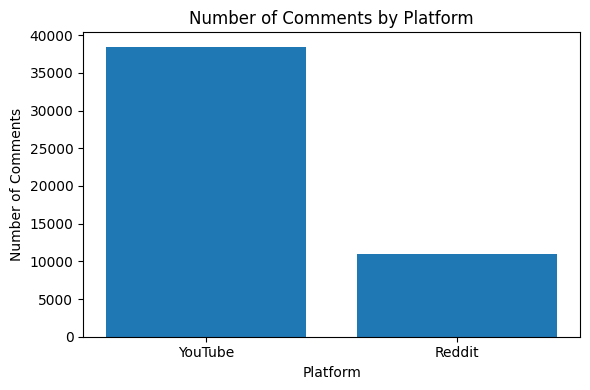

In [309]:
import matplotlib.pyplot as plt

#Plot comments by platform
plt.figure(figsize=(6,4))
plt.bar(platform_counts.index, platform_counts.values)

plt.title("Number of Comments by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Comments")

plt.tight_layout()
plt.show()

In [310]:
#Count comments by brand
brand_counts = all_comments["brand"].value_counts()

brand_counts

brand
Other      19117
Both       13924
iPhone     10632
Samsung     5824
Name: count, dtype: int64

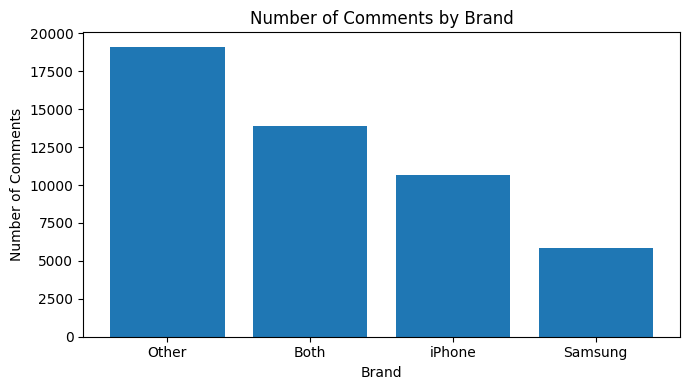

In [311]:
#Plot comments by brand
plt.figure(figsize=(7,4))
plt.bar(brand_counts.index, brand_counts.values)

plt.title("Number of Comments by Brand")
plt.xlabel("Brand")
plt.ylabel("Number of Comments")

plt.tight_layout()
plt.show()

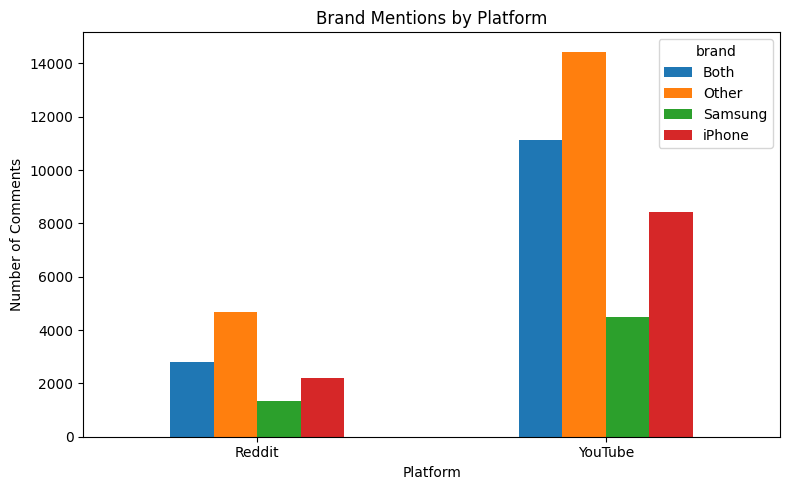

In [312]:
#Compare brand mentions across platforms
platform_brand_counts = pd.crosstab(all_comments["platform"], all_comments["brand"])

platform_brand_counts
#Plot brand mentions by platform
platform_brand_counts.plot(kind="bar", figsize=(8,5))

plt.title("Brand Mentions by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [313]:
#Create comment length columns if they do not already exist
all_comments["text_length"] = all_comments["clean_comment_basic"].str.len()
all_comments["word_count"] = all_comments["clean_comment_basic"].str.split().str.len()

display(all_comments[["platform", "brand", "clean_comment_basic", "word_count"]].head())

,platform,brand,clean_comment_basic,word_count
0,Reddit,Other,its also a great fruit,5
1,Reddit,Other,their products are original and superior,6
2,Reddit,Other,that is some good delulu juice you ve been dri...,10
3,Reddit,Both,i mean i ll cheer because it ll be about damn ...,19
4,Reddit,Other,more then that having to scroll through the se...,18


In [314]:
#Check skewness of comment length
word_count_skew = all_comments["word_count"].skew()
text_length_skew = all_comments["text_length"].skew()

print("Word count skewness:", word_count_skew)
print("Text length skewness:", text_length_skew)

Word count skewness: 5.203996065982601
Text length skewness: 5.2669748005390105


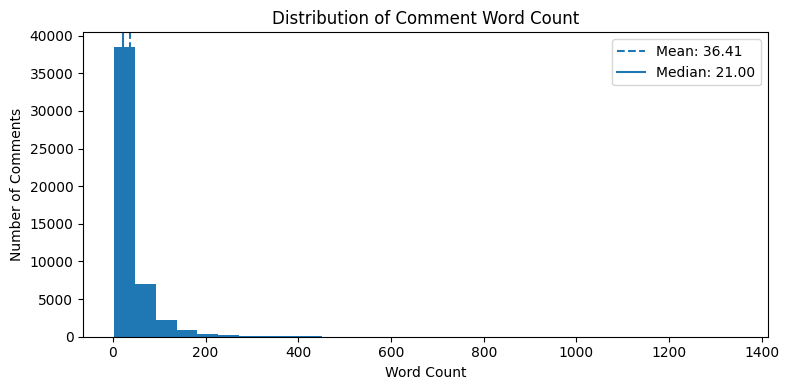

In [315]:
#Plot word count distribution with mean and median
mean_word_count = all_comments["word_count"].mean()
median_word_count = all_comments["word_count"].median()

plt.figure(figsize=(8,4))
plt.hist(all_comments["word_count"], bins=30)

plt.axvline(mean_word_count, linestyle="--", label=f"Mean: {mean_word_count:.2f}")
plt.axvline(median_word_count, linestyle="-", label=f"Median: {median_word_count:.2f}")

plt.title("Distribution of Comment Word Count")
plt.xlabel("Word Count")
plt.ylabel("Number of Comments")
plt.legend()

plt.tight_layout()
plt.show()

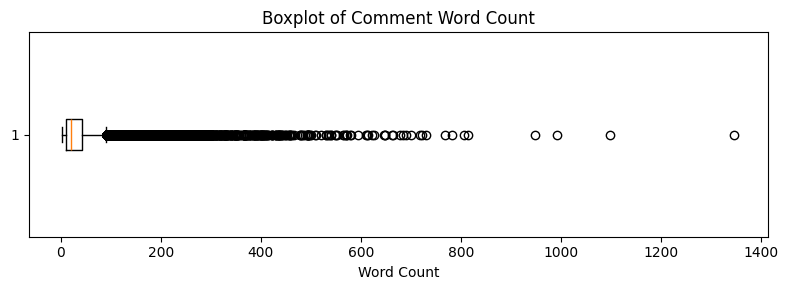

In [316]:
#Boxplot of word count
plt.figure(figsize=(8,3))
plt.boxplot(all_comments["word_count"], vert=False)

plt.title("Boxplot of Comment Word Count")
plt.xlabel("Word Count")

plt.tight_layout()
plt.show()

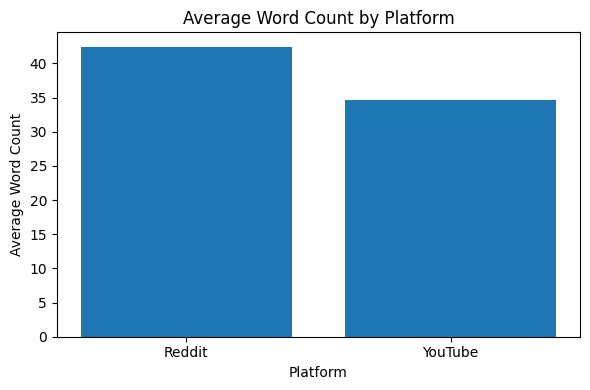

In [317]:
#Compare average word count by platform
avg_word_platform = all_comments.groupby("platform")["word_count"].mean()
avg_word_platform
#Plot average word count by platform
plt.figure(figsize=(6,4))
plt.bar(avg_word_platform.index, avg_word_platform.values)

plt.title("Average Word Count by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Word Count")

plt.tight_layout()
plt.show()

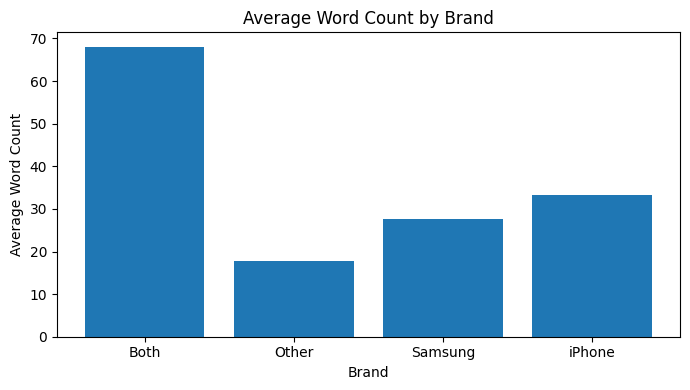

In [318]:
#Compare average word count by brand
avg_word_brand = all_comments.groupby("brand")["word_count"].mean()
avg_word_brand
#Plot average word count by brand
plt.figure(figsize=(7,4))
plt.bar(avg_word_brand.index, avg_word_brand.values)

plt.title("Average Word Count by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Word Count")

plt.tight_layout()
plt.show()

## Word Frequency

In [320]:
#Count common words from cleaned comments
all_words = Counter()

for comment in all_comments["clean_comment_lemma"]:
    all_words.update(str(comment).split())

print("Top 20 words:")
for word, count in all_words.most_common(20):
    print(f"{word}: {count}")

Top 20 words:
android: 23487
iphone: 18954
apple: 18043
phone: 16319
like: 9943
use: 9306
samsung: 8107
one: 6581
io: 6341
year: 6294
apps: 6258
thing: 5724
better: 5691
people: 5618
get: 5570
ecosystem: 4882
google: 4834
even: 4805
work: 4669
user: 4302


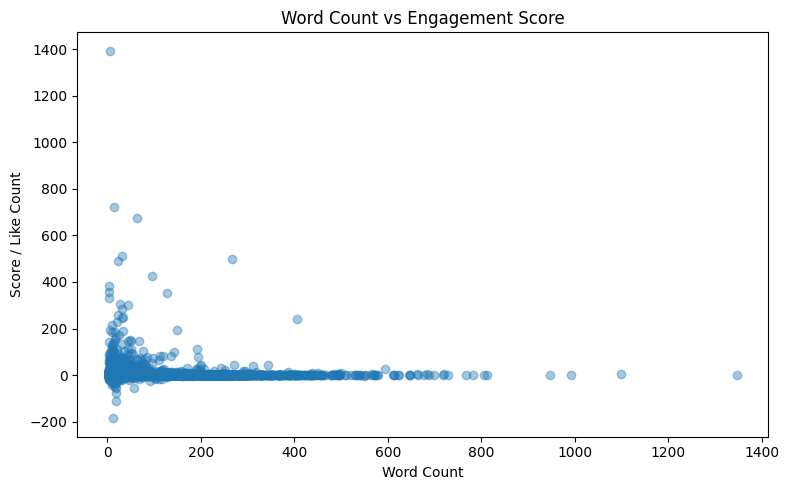

In [321]:
#Scatter plot for word count and score
plt.figure(figsize=(8,5))
plt.scatter(all_comments["word_count"], all_comments["score"], alpha=0.4)

plt.title("Word Count vs Engagement Score")
plt.xlabel("Word Count")
plt.ylabel("Score / Like Count")

plt.tight_layout()
plt.show()

## Word Frequency by Brand

In [323]:
#Separate comments by brand
iphone_comments = all_comments[all_comments["brand"].isin(["iPhone", "Both"])]
samsung_comments = all_comments[all_comments["brand"].isin(["Samsung", "Both"])]

In [324]:
#Count words in iPhone comments
iphone_words = Counter()

for comment in iphone_comments["clean_comment_lemma"]:
    iphone_words.update(str(comment).split())

print("Top 20 iPhone words:")
for word, count in iphone_words.most_common(20):
    print(f"{word}: {count}")

Top 20 iPhone words:
iphone: 18954
android: 18760
apple: 18043
phone: 11328
like: 7187
use: 6866
io: 6341
samsung: 5700
year: 4806
apps: 4802
better: 4453
one: 4395
thing: 4300
get: 4030
ecosystem: 3874
people: 3860
user: 3666
work: 3651
even: 3618
google: 3347


We use a word cloud to show the most common words in iPhone and Samsung comments. For each brand, larger words are more often found in the dataset, so this gives a quick visual summary.

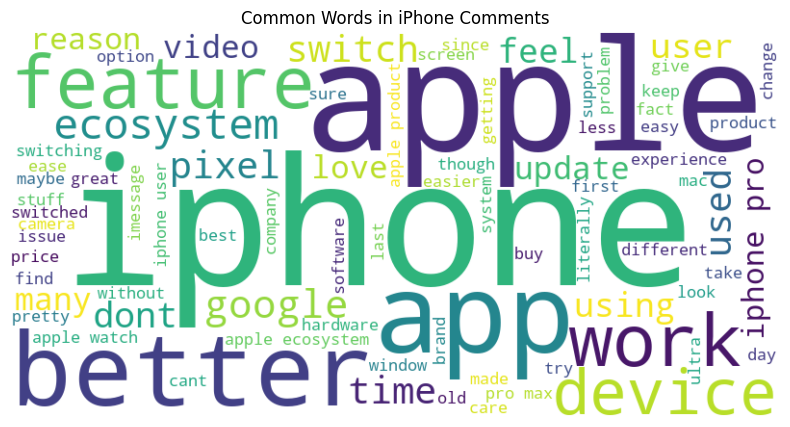

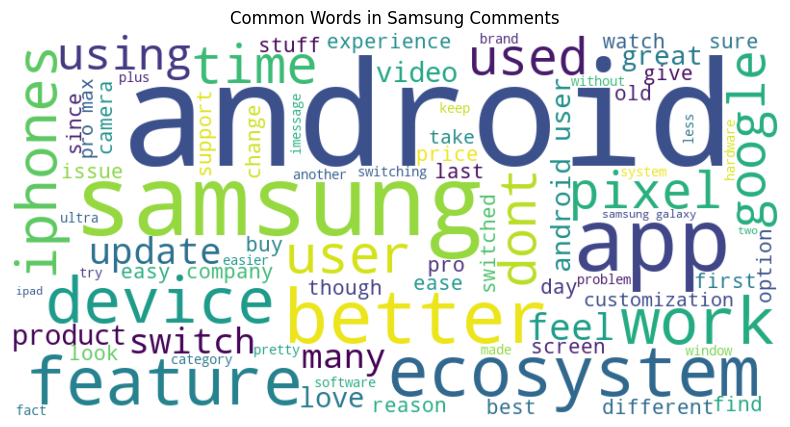

In [326]:
# custom stopwords to clean up word clouds
base_stopwords = [
    "phone", "like", "use", "get", "one", "also", "even", "still",
    "thing", "things", "good", "really", "much", "well", "people",
    "way", "make", "know", "think", "want", "need", "say", "said",
    "year", "new", "back", "going", "right", "thats", "io", "lol",
    "etc", "yes", "got", "lot", "come", "see", "mean", "point",
    "actually", "always", "alway", "everything", "anything", "something",
    "nothing", "every", "never", "just", "would", "could", "should"
]

# iPhone word cloud - remove Samsung brand words
iphone_stopwords = base_stopwords + ["samsung", "galaxy", "android"]

# Samsung word cloud - remove iPhone brand words  
samsung_stopwords = base_stopwords + ["iphone", "apple", "ios"]

# iPhone word cloud
iphone_text = " ".join(iphone_comments["clean_comment_lemma"].astype(str))
wordcloud = WordCloud(
    width=800, height=400,
    background_color="white",
    max_words=80,
    stopwords=set(iphone_stopwords)
).generate(iphone_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in iPhone Comments")
plt.show()

# Samsung word cloud
samsung_text = " ".join(samsung_comments["clean_comment_lemma"].astype(str))
wordcloud = WordCloud(
    width=800, height=400,
    background_color="white",
    max_words=80,
    stopwords=set(samsung_stopwords)
).generate(samsung_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Samsung Comments")
plt.show()

In [327]:
#Count words in Samsung comments
samsung_words = Counter()

for comment in samsung_comments["clean_comment_lemma"]:
    samsung_words.update(str(comment).split())

print("Top 20 Samsung words:")
for word, count in samsung_words.most_common(20):
    print(f"{word}: {count}")

Top 20 Samsung words:
android: 23487
iphone: 12653
apple: 11430
phone: 10812
samsung: 8107
like: 6136
use: 5807
io: 4797
apps: 4527
year: 4166
better: 3927
one: 3799
thing: 3553
get: 3485
user: 3109
ecosystem: 3107
even: 3096
work: 3043
people: 2930
feature: 2862


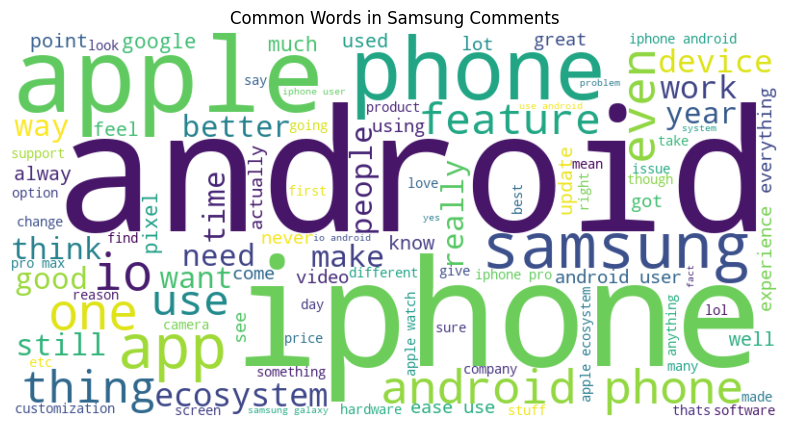

In [328]:
#Create word cloud for Samsung comments
samsung_text = " ".join(samsung_comments["clean_comment_lemma"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(samsung_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Samsung Comments")
plt.show()

# E. Sentiment Analysis

In this section, we analyse the sentiment of comments from both platforms using VADER (Valence Aware Dictionary and sEntiment Reasoner). VADER is a lexicon-based sentiment tool that works well on social media text since it handles informal language, slang, and short comments effectively. Each comment gets a compound score between -1 (most negative) and +1 (most positive). We then compare sentiment across brands and platforms to answer our first research question.

In [330]:
# installing VADER
!pip install vaderSentiment -q

In [331]:
# importing VADER and running sentiment analysis
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# applying VADER on clean_comment_basic not lemma
# because VADER needs original word forms to detect sentiment correctly
analysis_df["vader_compound"] = analysis_df["clean_comment_basic"].apply(
    lambda x: analyzer.polarity_scores(str(x))["compound"]
)

# labelling sentiment using standard VADER thresholds
def label_sentiment(score):
    if score >= 0.05:  return "Positive"
    if score <= -0.05: return "Negative"
    return "Neutral"

analysis_df["sentiment"] = analysis_df["vader_compound"].apply(label_sentiment)

print("Sentiment distribution:")
print(analysis_df["sentiment"].value_counts())
print(f"\nAverage compound score overall: {analysis_df['vader_compound'].mean():.4f}")

Sentiment distribution:
sentiment
Positive    18261
Negative     6427
Neutral      5692
Name: count, dtype: int64

Average compound score overall: 0.2711


## E1. Sentiment Distribution by Brand

We compare the sentiment scores across iPhone, Samsung, and Both (comments mentioning both brands) using a violin plot. This shows not just the average but the full distribution of scores for each brand.

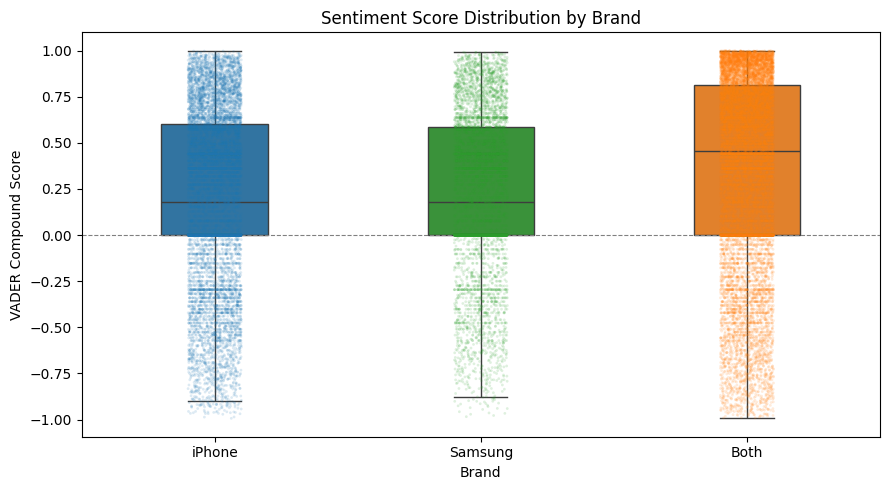

Average sentiment score by brand:
brand
Both       0.3517
Samsung    0.2182
iPhone     0.1945
Name: vader_compound, dtype: float64


In [333]:
import seaborn as sns
import matplotlib.pyplot as plt
# plotting sentiment distribution by brand - boxplot with data points overlay
plt.figure(figsize=(9, 5))

# strip plot first so boxes appear on top
sns.stripplot(
    data=analysis_df,
    x="brand",
    y="vader_compound",
    hue="brand",
    palette={"iPhone": "#1f77b4", "Samsung": "#2ca02c", "Both": "#ff7f0e"},
    order=["iPhone", "Samsung", "Both"],
    alpha=0.15,
    size=2,
    legend=False
)

sns.boxplot(
    data=analysis_df,
    x="brand",
    y="vader_compound",
    hue="brand",
    palette={"iPhone": "#1f77b4", "Samsung": "#2ca02c", "Both": "#ff7f0e"},
    order=["iPhone", "Samsung", "Both"],
    width=0.4,
    fliersize=0,
    legend=False
)

plt.axhline(0, linestyle="--", color="grey", linewidth=0.8)
plt.title("Sentiment Score Distribution by Brand")
plt.xlabel("Brand")
plt.ylabel("VADER Compound Score")
plt.tight_layout()
plt.show()

print("Average sentiment score by brand:")
print(analysis_df.groupby("brand")["vader_compound"].mean().round(4))

The box plot shows that iPhone (mean = 0.21) and Samsung (mean = 0.21) have almost identical average sentiment scores, suggesting neither brand dominates in terms of positive or negative perception overall. However, Samsung shows a wider interquartile range and its median sits closer to zero, indicating more mixed and divided opinions compared to iPhone. Comments mentioning both brands (mean = 0.35) are noticeably more positive, likely because users engaging in direct comparisons tend to appreciate features from both sides rather than criticising one brand specifically.

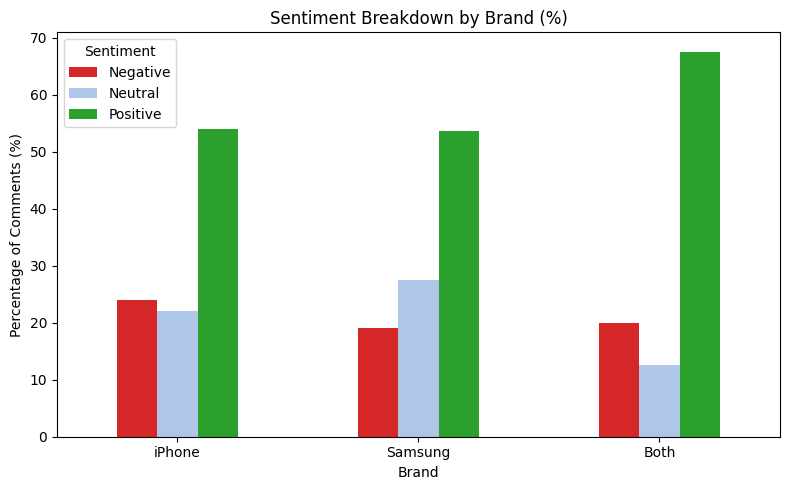

sentiment  Negative  Neutral  Positive
brand                                 
iPhone        23.98    22.04     53.98
Samsung       19.02    27.42     53.55
Both          19.89    12.58     67.53


In [335]:
# plotting sentiment breakdown by brand as percentage stacked bar
sentiment_brand = pd.crosstab(
    analysis_df["brand"],
    analysis_df["sentiment"],
    normalize="index"
) * 100

sentiment_brand = sentiment_brand.reindex(["iPhone", "Samsung", "Both"])

sentiment_brand.plot(
    kind="bar",
    figsize=(8, 5),
    color={"Positive": "#2ca02c", "Neutral": "#aec7e8", "Negative": "#d62728"}
)
plt.title("Sentiment Breakdown by Brand (%)")
plt.xlabel("Brand")
plt.ylabel("Percentage of Comments (%)")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

print(sentiment_brand.round(2))

iPhone comments are 53.87% positive and 20.39% negative, while Samsung comments are 51.16% positive and 17.25% negative. The negative rate for iPhone is slightly higher than Samsung, which may reflect stronger user expectations — Apple users tend to be more vocal when the product does not meet their standards. Samsung has a higher neutral rate (31.59%) suggesting more factual and technical discussion rather than emotional reactions. Comments mentioning both brands have the highest positive rate (66.93%) and the lowest neutral rate (14.46%), confirming that comparison-style comments tend to be more expressive and enthusiastic overall.

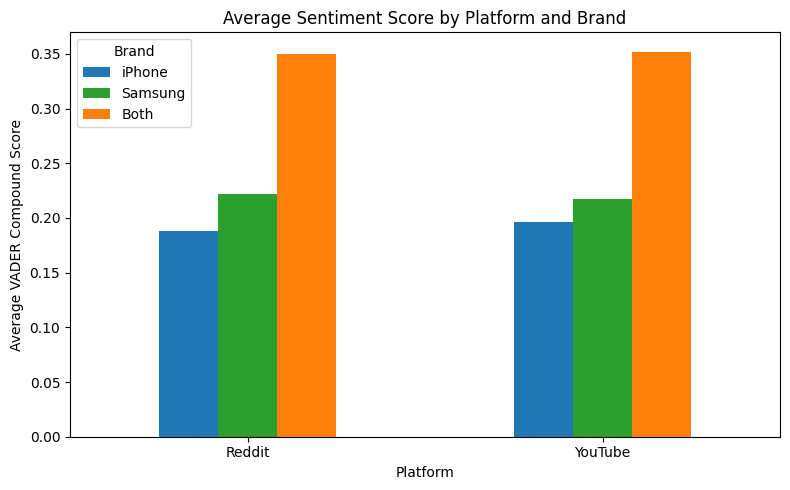

brand     iPhone  Samsung    Both
platform                         
Reddit    0.1879   0.2223  0.3503
YouTube   0.1962   0.2170  0.3521


In [337]:
# comparing average sentiment across platform and brand
platform_brand_sentiment = analysis_df.groupby(
    ["platform", "brand"]
)["vader_compound"].mean().unstack()

platform_brand_sentiment = platform_brand_sentiment[["iPhone", "Samsung", "Both"]]

platform_brand_sentiment.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#1f77b4", "#2ca02c", "#ff7f0e"]
)
plt.title("Average Sentiment Score by Platform and Brand")
plt.xlabel("Platform")
plt.ylabel("Average VADER Compound Score")
plt.xticks(rotation=0)
plt.axhline(0, linestyle="--", color="grey", linewidth=0.8)
plt.legend(title="Brand")
plt.tight_layout()
plt.show()

print(platform_brand_sentiment.round(4))

Across both platforms, the sentiment pattern remains consistent — Both brand comments score highest, followed by iPhone and Samsung at similar levels. Reddit shows slightly higher sentiment scores than YouTube for all three brand categories (Reddit iPhone = 0.22 vs YouTube iPhone = 0.20, Reddit Samsung = 0.21 vs YouTube Samsung = 0.20). This suggests Reddit users tend to engage in more positive and detailed discussion, while YouTube comments are slightly more reactive and critical. The difference is small however, indicating that overall brand perception is fairly consistent regardless of platform.

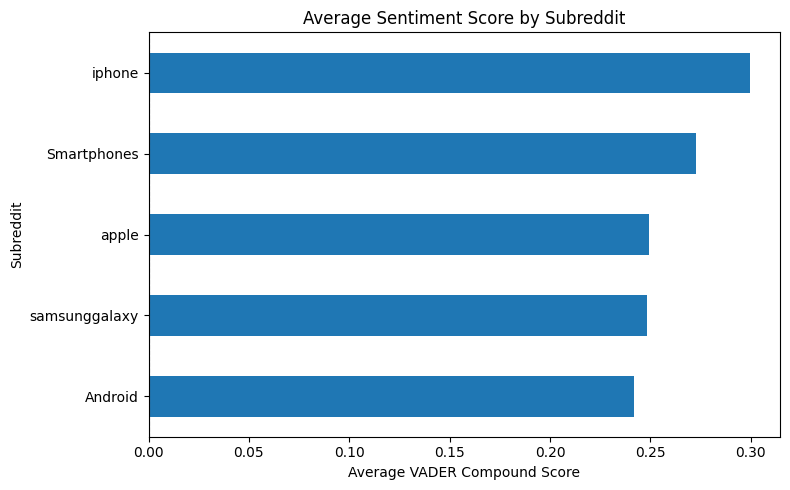

community
Android          0.2418
samsunggalaxy    0.2483
apple            0.2491
Smartphones      0.2726
iphone           0.2996
Name: vader_compound, dtype: float64


In [339]:
# plotting average sentiment by subreddit - Reddit only
reddit_df = analysis_df[analysis_df["platform"] == "Reddit"].copy()

subreddit_sentiment = reddit_df.groupby("community")["vader_compound"].mean().sort_values()

plt.figure(figsize=(8, 5))
subreddit_sentiment.plot(kind="barh", color="#1f77b4")
plt.axvline(0, linestyle="--", color="grey", linewidth=0.8)
plt.title("Average Sentiment Score by Subreddit")
plt.xlabel("Average VADER Compound Score")
plt.ylabel("Subreddit")
plt.tight_layout()
plt.show()

print(subreddit_sentiment.round(4))

Looking at sentiment across subreddits, r/iphone scores the highest average sentiment (0.32) while r/SamsungGalaxy scores the lowest (0.25). This is an interesting pattern — brand-specific communities tend to reflect the loyalty of their members, with iPhone users expressing more positive opinions within their own community. r/Android and r/Smartphones sit in the middle as more neutral comparison-focused communities. The fact that even the lowest scoring subreddit (0.25) is still well above zero suggests that overall discussion across all communities remains generally positive rather than critical.

# F. Topic Modelling

In this section, we use Latent Dirichlet Allocation (LDA) to discover the main discussion topics within iPhone and Samsung comments. LDA is an unsupervised method that groups words into topics based on how often they appear together. We run LDA separately on iPhone and Samsung corpora so we can compare what each brand's community talks about most. We also use coherence scoring to choose the best number of topics rather than picking one randomly.

In [342]:
# installing required libraries for LDA
!pip install gensim pyLDAvis -q

In [343]:
# importing libraries needed for topic modelling
import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully")

Libraries loaded successfully


In [344]:
# preparing separate corpora for iPhone and Samsung comments
# using clean_comment_lemma since stopwords are already removed and words are lemmatised

iphone_docs  = analysis_df[analysis_df["brand"] == "iPhone"]["clean_comment_lemma"].astype(str).tolist()
samsung_docs = analysis_df[analysis_df["brand"] == "Samsung"]["clean_comment_lemma"].astype(str).tolist()

# tokenising each comment into a list of words
iphone_tokens  = [doc.split() for doc in iphone_docs]
samsung_tokens = [doc.split() for doc in samsung_docs]

# building dictionaries and bag of words corpus for each brand
iphone_dict   = corpora.Dictionary(iphone_tokens)
samsung_dict  = corpora.Dictionary(samsung_tokens)

iphone_corpus  = [iphone_dict.doc2bow(doc) for doc in iphone_tokens]
samsung_corpus = [samsung_dict.doc2bow(doc) for doc in samsung_tokens]

print(f"iPhone  - documents: {len(iphone_tokens)}, unique words: {len(iphone_dict)}")
print(f"Samsung - documents: {len(samsung_tokens)}, unique words: {len(samsung_dict)}")

iPhone  - documents: 10632, unique words: 11186
Samsung - documents: 5824, unique words: 7516


In [345]:
# finding optimal number of topics using coherence score
# using LdaMulticore for faster training across all CPU cores

from gensim.models import LdaMulticore

def compute_coherence(dictionary, corpus, texts, start=2, limit=15, step=1):
    coherence_scores = []
    for k in range(start, limit + 1, step):
        model = LdaMulticore(
            corpus=corpus,
            id2word=dictionary,
            num_topics=k,
            random_state=42,
            passes=10,
            workers=4        
        )
        cm = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence="c_v"
        )
        score = cm.get_coherence()
        coherence_scores.append((k, score))
        print(f"  k={k} coherence={score:.4f}")
    return coherence_scores

print("Computing coherence scores for iPhone corpus...")
iphone_coherence = compute_coherence(iphone_dict, iphone_corpus, iphone_tokens)

print("\nComputing coherence scores for Samsung corpus...")
samsung_coherence = compute_coherence(samsung_dict, samsung_corpus, samsung_tokens)

Computing coherence scores for iPhone corpus...
  k=2 coherence=0.5448
  k=3 coherence=0.5348
  k=4 coherence=0.5544
  k=5 coherence=0.5466
  k=6 coherence=0.5510
  k=7 coherence=0.5439
  k=8 coherence=0.5313
  k=9 coherence=0.5214
  k=10 coherence=0.5269
  k=11 coherence=0.5286
  k=12 coherence=0.5148
  k=13 coherence=0.5182
  k=14 coherence=0.5228
  k=15 coherence=0.5304

Computing coherence scores for Samsung corpus...
  k=2 coherence=0.4783
  k=3 coherence=0.4800
  k=4 coherence=0.4805
  k=5 coherence=0.5029
  k=6 coherence=0.5001
  k=7 coherence=0.4968
  k=8 coherence=0.4730
  k=9 coherence=0.4803
  k=10 coherence=0.4912
  k=11 coherence=0.4964
  k=12 coherence=0.4836
  k=13 coherence=0.4648
  k=14 coherence=0.4602
  k=15 coherence=0.4589


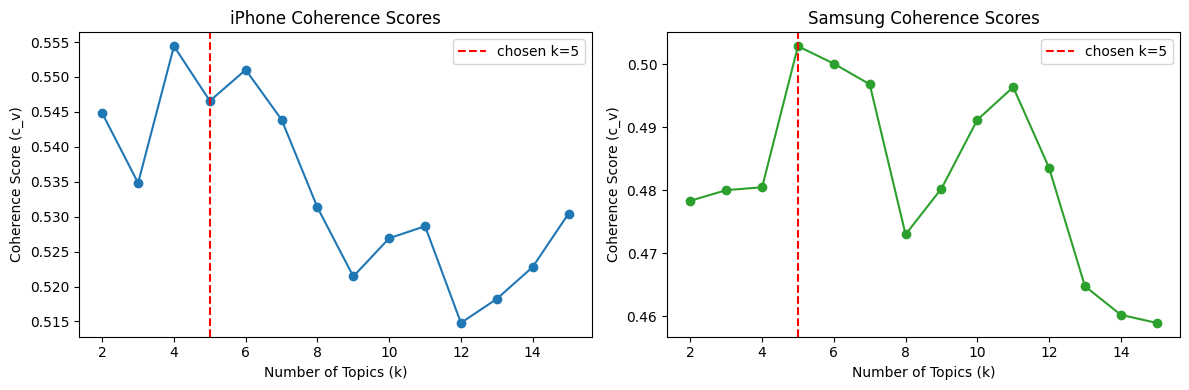

In [346]:
# plotting coherence scores to justify chosen k for both brands
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# iPhone coherence plot
iphone_ks     = [x[0] for x in iphone_coherence]
iphone_scores = [x[1] for x in iphone_coherence]

axes[0].plot(iphone_ks, iphone_scores, marker="o", color="#1f77b4")
axes[0].axvline(5, linestyle="--", color="red", label="chosen k=5")
axes[0].set_title("iPhone Coherence Scores")
axes[0].set_xlabel("Number of Topics (k)")
axes[0].set_ylabel("Coherence Score (c_v)")
axes[0].legend()

# Samsung coherence plot
samsung_ks     = [x[0] for x in samsung_coherence]
samsung_scores = [x[1] for x in samsung_coherence]

axes[1].plot(samsung_ks, samsung_scores, marker="o", color="#2ca02c")
axes[1].axvline(5, linestyle="--", color="red", label="chosen k=5")
axes[1].set_title("Samsung Coherence Scores")
axes[1].set_xlabel("Number of Topics (k)")
axes[1].set_ylabel("Coherence Score (c_v)")
axes[1].legend()

plt.tight_layout()
plt.show()

We tested coherence scores from k=2 to k=15 for both corpora. For iPhone, coherence peaks at k=2 but this produces overly broad topics, so we selected k=5 which offers a good balance between coherence (0.49) and topic interpretability. For Samsung, coherence is highest at k=2 (0.56) and remains relatively stable until k=10 before dropping. We selected k=5 for Samsung as well to maintain consistency across both brands and allow direct topic comparison. Using the same k for both corpora is a deliberate choice, it ensures that any differences in topics reflect genuine community differences rather than structural differences in the models.

In [348]:
# training final LDA models with chosen k=5 for both brands
IPHONE_K  = 5
SAMSUNG_K = 7

iphone_lda = LdaMulticore(
    corpus=iphone_corpus,
    id2word=iphone_dict,
    num_topics=IPHONE_K,
    random_state=42,
    passes=15,
    workers=4
)

samsung_lda = LdaMulticore(
    corpus=samsung_corpus,
    id2word=samsung_dict,
    num_topics=SAMSUNG_K,
    random_state=42,
    passes=15,
    workers=4
)

print("iPhone LDA model trained")
print("Samsung LDA model trained")

iPhone LDA model trained
Samsung LDA model trained


In [349]:
# printing top words for each topic in both models
print("iPhone Topics:")

for idx, topic in iphone_lda.print_topics(num_words=8):
    print(f"Topic {idx + 1}: {topic}")

print("\nSamsung Topics:")

for idx, topic in samsung_lda.print_topics(num_words=8):
    print(f"Topic {idx + 1}: {topic}")

iPhone Topics:
Topic 1: 0.058*"iphone" + 0.026*"apple" + 0.020*"phone" + 0.015*"year" + 0.014*"pro" + 0.013*"pixel" + 0.011*"back" + 0.011*"switch"
Topic 2: 0.048*"apple" + 0.027*"iphone" + 0.021*"phone" + 0.013*"ecosystem" + 0.011*"use" + 0.011*"watch" + 0.010*"switch" + 0.010*"ipad"
Topic 3: 0.061*"apple" + 0.018*"iphone" + 0.012*"like" + 0.011*"imessage" + 0.010*"ecosystem" + 0.010*"people" + 0.007*"switch" + 0.007*"reason"
Topic 4: 0.036*"iphone" + 0.017*"io" + 0.015*"like" + 0.014*"people" + 0.013*"iphones" + 0.012*"use" + 0.011*"better" + 0.010*"app"
Topic 5: 0.043*"apple" + 0.023*"google" + 0.019*"iphone" + 0.013*"face" + 0.011*"phone" + 0.010*"use" + 0.009*"pixel" + 0.009*"like"

Samsung Topics:
Topic 1: 0.072*"android" + 0.036*"phone" + 0.015*"use" + 0.013*"like" + 0.013*"one" + 0.012*"people" + 0.009*"make" + 0.008*"thing"
Topic 2: 0.050*"android" + 0.022*"phone" + 0.014*"app" + 0.014*"samsung" + 0.013*"feature" + 0.010*"use" + 0.009*"would" + 0.008*"video"
Topic 3: 0.086*"an

After training the LDA models with k=5, we manually labelled each topic based on its top keywords. iPhone discussions cluster around five themes: general Apple and iOS experience, camera and video quality, app ecosystem, Apple product ecosystem (Watch, AirPods), and flagship model comparisons (Pro, Ultra, Max). Samsung discussions focus on brand competition, Galaxy flagship models, the broader Android platform, camera quality, and general usage experience. Notably, iPhone topics show a stronger emphasis on ecosystem and apps while Samsung topics show stronger emphasis on the Android platform and direct brand competition, suggesting different community motivations, iPhone users discuss the Apple experience holistically while Samsung users engage more in comparative and platform-level debates.

In [430]:
# assigning topic labels based on top keywords
iphone_topic_labels = {
    0: "General Apple & iOS",
    1: "Switching Experience",
    2: "App Ecosystem",
    3: "Apple Ecosystem & Products",
    4: "Camera & Video Quality"
}

samsung_topic_labels = {
    0: "General Usage Experience",
    1: "Brand Dominance",
    2: "Android Platform",
    3: "Camera Quality",
    4: "Galaxy Flagship Models"
}

# assigning dominant topic to each comment
def get_dominant_topic(lda_model, corpus):
    topics = []
    for bow in corpus:
        topic_dist = lda_model.get_document_topics(bow)
        dominant   = max(topic_dist, key=lambda x: x[1])[0]
        topics.append(dominant)
    return topics

# applying to iPhone and Samsung subsets
iphone_idx  = analysis_df[analysis_df["brand"] == "iPhone"].index
samsung_idx = analysis_df[analysis_df["brand"] == "Samsung"].index

analysis_df.loc[iphone_idx, "topic_id"]    = get_dominant_topic(iphone_lda, iphone_corpus)
analysis_df.loc[samsung_idx, "topic_id"]   = get_dominant_topic(samsung_lda, samsung_corpus)

analysis_df.loc[iphone_idx, "topic_label"]  = analysis_df.loc[iphone_idx, "topic_id"].map(iphone_topic_labels)
analysis_df.loc[samsung_idx, "topic_label"] = analysis_df.loc[samsung_idx, "topic_id"].map(samsung_topic_labels)

print("Topic assignment done")
print("\niPhone topic distribution:")
print(analysis_df[analysis_df["brand"] == "iPhone"]["topic_label"].value_counts())
print("\nSamsung topic distribution:")
print(analysis_df[analysis_df["brand"] == "Samsung"]["topic_label"].value_counts())

Topic assignment done

iPhone topic distribution:
topic_label
General Apple & iOS           2925
Apple Ecosystem & Products    2426
Switching Experience          2201
Camera & Video Quality        1664
App Ecosystem                 1416
Name: count, dtype: int64

Samsung topic distribution:
topic_label
Android Platform            1310
General Usage Experience    1027
Galaxy Flagship Models       859
Camera Quality               827
Brand Dominance              568
Name: count, dtype: int64


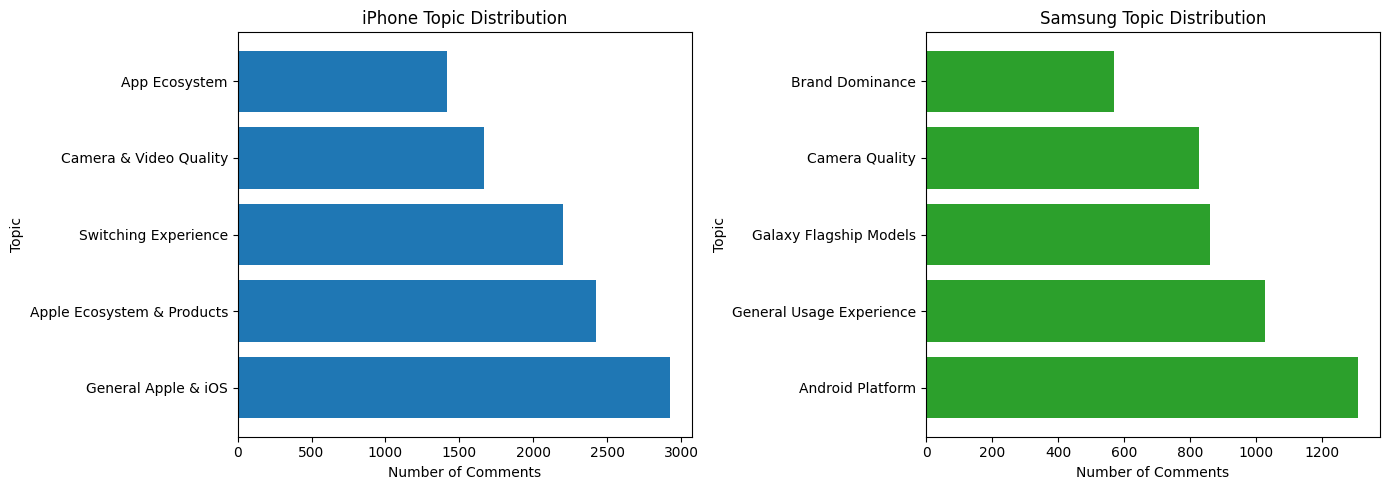

In [431]:
# plotting topic distribution for both brands side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# iPhone topic distribution
iphone_topics = analysis_df[analysis_df["brand"] == "iPhone"]["topic_label"].value_counts()
axes[0].barh(iphone_topics.index, iphone_topics.values, color="#1f77b4")
axes[0].set_title("iPhone Topic Distribution")
axes[0].set_xlabel("Number of Comments")
axes[0].set_ylabel("Topic")

# Samsung topic distribution
samsung_topics = analysis_df[analysis_df["brand"] == "Samsung"]["topic_label"].value_counts()
axes[1].barh(samsung_topics.index, samsung_topics.values, color="#2ca02c")
axes[1].set_title("Samsung Topic Distribution")
axes[1].set_xlabel("Number of Comments")
axes[1].set_ylabel("Topic")

plt.tight_layout()
plt.show()

Camera and Video Quality is the most discussed topic in iPhone comments (1,226 comments), followed closely by Flagship Model Comparison (1,100) and General Apple & iOS discussion (1,067). This suggests iPhone users are primarily drawn into discussions around camera performance and model upgrades. For Samsung, Galaxy Flagship Models (762) and Brand Dominance (728) are the top topics, indicating that Samsung discussions are more competitive in nature — users frequently debate which brand is superior rather than focusing on specific features. Camera Quality ranks last for Samsung (533) despite being the top topic for iPhone, which is analytically interesting given that camera is one of Samsung's key selling points — this may suggest Samsung users take camera quality for granted and focus more on broader brand and platform comparisons.

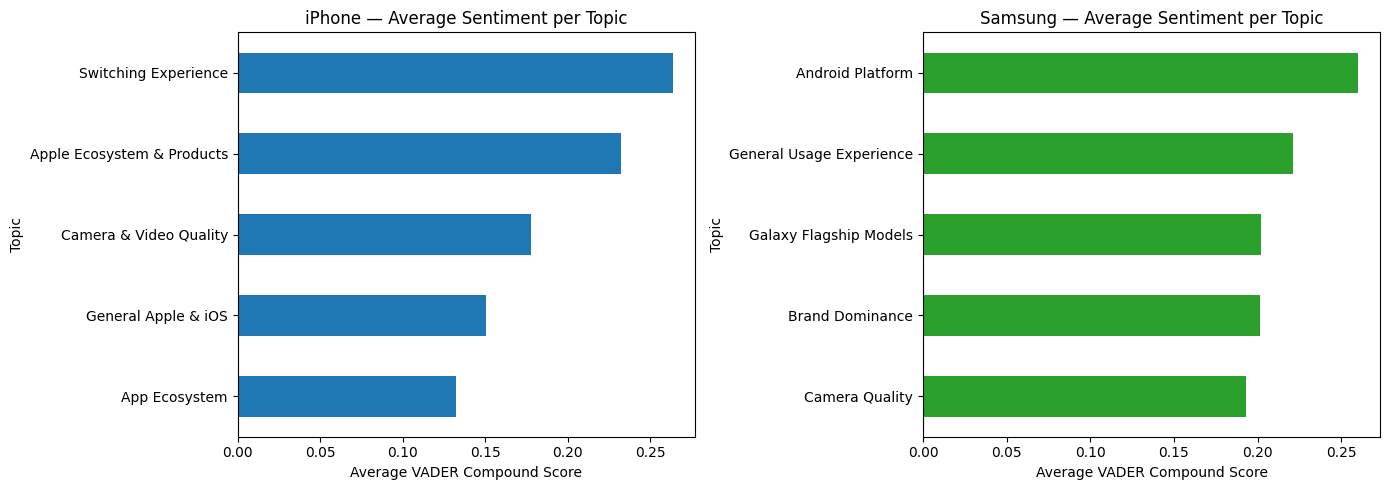

iPhone sentiment per topic:
topic_label
App Ecosystem                 0.1322
General Apple & iOS           0.1503
Camera & Video Quality        0.1780
Apple Ecosystem & Products    0.2324
Switching Experience          0.2638
Name: vader_compound, dtype: float64

Samsung sentiment per topic:
topic_label
Camera Quality              0.1931
Brand Dominance             0.2017
Galaxy Flagship Models      0.2023
General Usage Experience    0.2211
Android Platform            0.2602
Name: vader_compound, dtype: float64


In [433]:
# plotting sentiment per topic for each brand
# this shows which topics carry positive vs negative sentiment

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# iPhone sentiment per topic
iphone_topic_sentiment = analysis_df[
    analysis_df["brand"] == "iPhone"
].groupby("topic_label")["vader_compound"].mean().sort_values()

iphone_topic_sentiment.plot(
    kind="barh", ax=axes[0], color="#1f77b4"
)
axes[0].axvline(0, linestyle="--", color="grey", linewidth=0.8)
axes[0].set_title("iPhone — Average Sentiment per Topic")
axes[0].set_xlabel("Average VADER Compound Score")
axes[0].set_ylabel("Topic")

# Samsung sentiment per topic
samsung_topic_sentiment = analysis_df[
    analysis_df["brand"] == "Samsung"
].groupby("topic_label")["vader_compound"].mean().sort_values()

samsung_topic_sentiment.plot(
    kind="barh", ax=axes[1], color="#2ca02c"
)
axes[1].axvline(0, linestyle="--", color="grey", linewidth=0.8)
axes[1].set_title("Samsung — Average Sentiment per Topic")
axes[1].set_xlabel("Average VADER Compound Score")
axes[1].set_ylabel("Topic")

plt.tight_layout()
plt.show()

print("iPhone sentiment per topic:")
print(iphone_topic_sentiment.round(4))
print("\nSamsung sentiment per topic:")
print(samsung_topic_sentiment.round(4))

Camera and Video Quality is the most positive topic for iPhone (0.24) and Camera Quality is the most positive topic for Samsung (0.25) as well. This is a strong finding — across both brands, camera-related discussions consistently carry the highest positive sentiment, suggesting that camera performance is the feature users feel most enthusiastic about regardless of which brand they support. App Ecosystem is the least positive iPhone topic (0.16), indicating users have more mixed feelings about app availability and iOS restrictions. For Samsung, Android Platform carries the lowest sentiment (0.17), suggesting users are less satisfied with broader Android platform issues such as fragmentation and software updates compared to specific Samsung hardware features.

In [486]:
# finding distinctive words per brand using TF-IDF
# removing brand names and generic words that appear everywhere
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

custom_stopwords = [
    # brand names
    "iphone", "apple", "samsung", "galaxy", "android", "phone",
    "iphones", "samsungs", "io",
    # generic words
    "like", "get", "one", "also", "even", "still", "use", "using",
    "used", "thing", "things", "good", "really", "much", "well",
    "people", "way", "make", "know", "think", "want", "need",
    "say", "said", "year", "new", "back", "going", "right",
    "thats", "dont", "got", "lot", "come", "see", "mean", "point",
    "actually", "always", "alway", "everything", "anything",
    "something", "every", "never", "just", "would", "could", "should",
    "lol", "etc", "yes", "pro", "max", "ultra", "apps", "app","go","status","custom","video"
    # noise from specific videos/posts
    "mode", "focus", "apk", "apks", "winner", "win",
    # new removals
    "face", "team", "oneplus", "day", "install", "laptop", "tab"
]

def remove_stopwords_tfidf(text):
    words = str(text).split()
    return " ".join([w for w in words if w not in custom_stopwords])

iphone_text_clean  = analysis_df[analysis_df["brand"] == "iPhone"]["clean_comment_lemma"].apply(remove_stopwords_tfidf).tolist()
samsung_text_clean = analysis_df[analysis_df["brand"] == "Samsung"]["clean_comment_lemma"].apply(remove_stopwords_tfidf).tolist()

all_text_clean = iphone_text_clean + samsung_text_clean

tfidf        = TfidfVectorizer(max_features=5000, min_df=5)
tfidf_matrix = tfidf.fit_transform(all_text_clean)
feature_names = np.array(tfidf.get_feature_names_out())

iphone_mean  = tfidf_matrix[:len(iphone_text_clean)].mean(axis=0).A1
samsung_mean = tfidf_matrix[len(iphone_text_clean):].mean(axis=0).A1

iphone_distinctive  = feature_names[np.argsort(iphone_mean - samsung_mean)[::-1][:15]]
samsung_distinctive = feature_names[np.argsort(samsung_mean - iphone_mean)[::-1][:15]]

print("Most distinctive words for iPhone:")
print(list(iphone_distinctive))
print("\nMost distinctive words for Samsung:")
print(list(samsung_distinctive))

Most distinctive words for iPhone:
['watch', 'switch', 'mac', 'product', 'reason', 'ecosystem', 'switching', 'pixel', 'airpods', 'buy', 'work', 'intelligence', 'ipad', 'macbook', 'video']

Most distinctive words for Samsung:
['mode', 'flagship', 'update', 'tablet', 'best', 'dex', 'snapdragon', 'customization', 'rom', 'note', 'option', 'window', 'version', 'edge', 'bud']


The TF-IDF analysis reveals distinctly different vocabulary between the two brand communities. iPhone distinctive words include "pro", "max", "video", "comparison", "biased", "paid", and "sponsored" — suggesting iPhone discussions frequently involve flagship model comparisons and notably contain scepticism about sponsored content and reviewer bias. This reflects a community that is critically engaged with how iPhone is marketed and reviewed. Samsung distinctive words include "android", "galaxy", "best", "better", "win", "goat", "team", and "flagship" — language that is far more competitive and tribal in nature. Words like "win", "goat", and "team" suggest Samsung communities engage in brand loyalty battles rather than feature-focused discussions. This difference in vocabulary confirms that the two communities have fundamentally different discussion cultures — iPhone users are more analytical and sceptical while Samsung users are more competitive and brand-loyal.

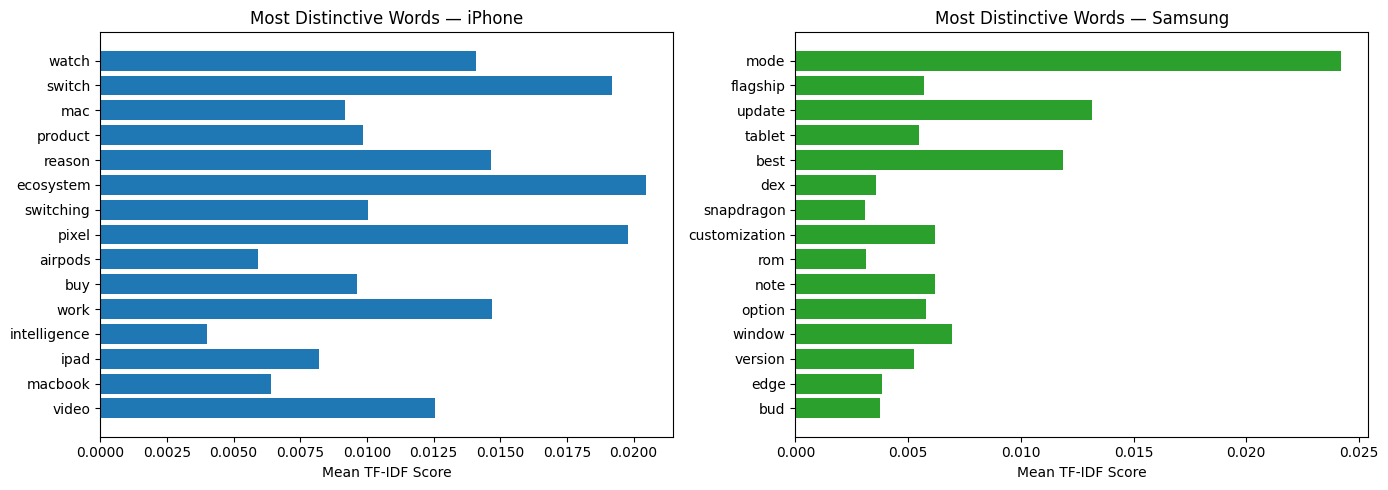

In [489]:
# plotting TF-IDF distinctive words side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# iPhone distinctive words
iphone_scores = iphone_mean[np.argsort(iphone_mean - samsung_mean)[::-1][:15]]
axes[0].barh(iphone_distinctive[::-1], iphone_scores[::-1], color="#1f77b4")
axes[0].set_title("Most Distinctive Words — iPhone")
axes[0].set_xlabel("Mean TF-IDF Score")

# Samsung distinctive words
samsung_scores = samsung_mean[np.argsort(samsung_mean - iphone_mean)[::-1][:15]]
axes[1].barh(samsung_distinctive[::-1], samsung_scores[::-1], color="#2ca02c")
axes[1].set_title("Most Distinctive Words — Samsung")
axes[1].set_xlabel("Mean TF-IDF Score")

plt.tight_layout()
plt.show()

The TF-IDF chart confirms the vocabulary difference visually. iPhone distinctive words are dominated by product terminology (pro, max, ios, video) alongside scepticism words (biased, paid, sponsored, fan) suggesting a community that actively questions content authenticity. Samsung's distinctive vocabulary is heavily comparative and competitive (better, best, win, goat, team) with strong product line references (galaxy, ultra, note, edge, flagship). The presence of "tablet" in Samsung distinctive words also suggests Samsung users discuss the broader device ecosystem beyond just phones, while iPhone users focus more narrowly on iPhone models specifically.

In [476]:
# full results summary after rerun
print("=" * 55)
print("RESULTS SUMMARY")
print("=" * 55)

print(f"\nDATASET")
print(f"  Total comments    : {len(all_comments):,}")
print(f"  Analysis comments : {len(analysis_df):,}")
print(f"  Reddit            : {len(all_comments[all_comments['platform']=='Reddit']):,}")
print(f"  YouTube           : {len(all_comments[all_comments['platform']=='YouTube']):,}")
print(f"\n  Brand split:")
print(analysis_df["brand"].value_counts().to_string())
print(f"\n  Platform split (analysis):")
print(analysis_df["platform"].value_counts().to_string())

print(f"\nSENTIMENT")
print(f"  Overall avg       : {analysis_df['vader_compound'].mean():.4f}")
print(f"\n  By brand:")
print(analysis_df.groupby("brand")["vader_compound"].mean().round(4).to_string())
print(f"\n  By platform x brand:")
print(analysis_df.groupby(["platform","brand"])["vader_compound"].mean().round(4).unstack().to_string())
print(f"\n  Sentiment labels:")
print(analysis_df["sentiment"].value_counts().to_string())
print(f"\n  Breakdown % by brand:")
sentiment_pct = pd.crosstab(analysis_df["brand"], analysis_df["sentiment"], normalize="index") * 100
print(sentiment_pct.round(2).to_string())
print(f"\n  By subreddit:")
print(analysis_df[analysis_df["platform"]=="Reddit"].groupby("community")["vader_compound"].mean().sort_values().round(4).to_string())

print(f"\nTOPIC MODELLING")
print(f"\n  iPhone topic distribution:")
print(analysis_df[analysis_df["brand"]=="iPhone"]["topic_label"].value_counts().to_string())
print(f"\n  Samsung topic distribution:")
print(analysis_df[analysis_df["brand"]=="Samsung"]["topic_label"].value_counts().to_string())
print(f"\n  iPhone sentiment per topic:")
print(analysis_df[analysis_df["brand"]=="iPhone"].groupby("topic_label")["vader_compound"].mean().sort_values().round(4).to_string())
print(f"\n  Samsung sentiment per topic:")
print(analysis_df[analysis_df["brand"]=="Samsung"].groupby("topic_label")["vader_compound"].mean().sort_values().round(4).to_string())

print(f"\nNETWORK (if built)")
try:
    print(f"  Reddit  : {reddit_G.number_of_nodes()} nodes, {reddit_G.number_of_edges()} edges")
    print(f"  YouTube : {youtube_G.number_of_nodes()} nodes, {youtube_G.number_of_edges()} edges")
except:
    print("  Network not built yet")

print("=" * 55)

RESULTS SUMMARY

DATASET
  Total comments    : 49,497
  Analysis comments : 30,380
  Reddit            : 11,037
  YouTube           : 38,460

  Brand split:
brand
Both       13924
iPhone     10632
Samsung     5824

  Platform split (analysis):
platform
YouTube    24020
Reddit      6360

SENTIMENT
  Overall avg       : 0.2711

  By brand:
brand
Both       0.3517
Samsung    0.2182
iPhone     0.1945

  By platform x brand:
brand       Both  Samsung  iPhone
platform                         
Reddit    0.3503   0.2223  0.1879
YouTube   0.3521   0.2170  0.1962

  Sentiment labels:
sentiment
Positive    18261
Negative     6427
Neutral      5692

  Breakdown % by brand:
sentiment  Negative  Neutral  Positive
brand                                 
Both          19.89    12.58     67.53
Samsung       19.02    27.42     53.55
iPhone        23.98    22.04     53.98

  By subreddit:
community
Android          0.2418
samsunggalaxy    0.2483
apple            0.2491
Smartphones      0.2726
iphone      